# Health Trends in Rwanda: Life Expectancy, Maternal Mortality and Under-Five Mortality

This analysis explores key health indicators in Rwanda using data from the World Health Organization.

The study focuses on:

• Life expectancy at birth  
• Maternal mortality ratio  
• Under-five mortality rate  

These indicators help evaluate healthcare system performance and population health progress.


In [3]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid") 


In [5]:
# Load datasets
causes_death = pd.read_csv(r"C:\Users\USER\Downloads\GHE_FULL_DD. Top causes of death.csv")
life_expectancy = pd.read_csv(r"C:\Users\USER\Downloads\RELAY_WHS.life expectancy datasets.csv")
maternal_mortality = pd.read_csv(r"C:\Users\USER\Downloads\RELAY_WHS.maternal mortality.csv")

under5_mortality = pd.read_csv(r"C:\Users\USER\Downloads\RELAY_WHS.under five mortality.csv")


Preview the data

In [6]:
life_expectancy.head()
maternal_mortality.head()
under5_mortality.head()
causes_death.head()

,DIM_COUNTRY_CODE,DIM_YEAR_CODE,DIM_GHECAUSE_TITLE,DIM_SEX_CODE,VAL_DTHS_RATE100K_NUMERIC
0,AFG,2021,Syphilis,BTSX,1.46
1,AFG,2021,Genital herpes,BTSX,0.00
2,AFG,2021,Diphtheria,BTSX,0.11
3,AFG,2021,African trypanosomiasis,BTSX,0.00
4,AFG,2021,Dengue,BTSX,0.00


In [8]:
rwanda_deaths = causes_death[causes_death["DIM_COUNTRY_CODE"] == "RWA"]
rwanda_deaths.head()

,DIM_COUNTRY_CODE,DIM_YEAR_CODE,DIM_GHECAUSE_TITLE,DIM_SEX_CODE,VAL_DTHS_RATE100K_NUMERIC
18626,RWA,2021,Syphilis,BTSX,1.87
18627,RWA,2021,Gonorrhoea,BTSX,0.02
18628,RWA,2021,Diphtheria,BTSX,0.03
18629,RWA,2021,Tetanus,BTSX,0.47
18630,RWA,2021,African trypanosomiasis,BTSX,0.00


In [9]:
rwanda_deaths = causes_death[causes_death["DIM_COUNTRY_CODE"] == "RWA"]
rwanda_deaths.head()

,DIM_COUNTRY_CODE,DIM_YEAR_CODE,DIM_GHECAUSE_TITLE,DIM_SEX_CODE,VAL_DTHS_RATE100K_NUMERIC
18626,RWA,2021,Syphilis,BTSX,1.87
18627,RWA,2021,Gonorrhoea,BTSX,0.02
18628,RWA,2021,Diphtheria,BTSX,0.03
18629,RWA,2021,Tetanus,BTSX,0.47
18630,RWA,2021,African trypanosomiasis,BTSX,0.00


In [15]:
rwanda_life = life_expectancy[life_expectancy["GEO_NAME_SHORT"] == "Rwanda"]
rwanda_life.head()

,IND_ID,IND_CODE,IND_UUID,IND_PER_CODE,DIM_TIME,DIM_TIME_TYPE,DIM_GEO_CODE_M49,DIM_GEO_CODE_TYPE,DIM_PUBLISH_STATE_CODE,IND_NAME,GEO_NAME_SHORT,DIM_SEX,AMOUNT_N
171,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2000,YEAR,646,COUNTRY,PUBLISHED,Life expectancy (at birth),Rwanda,FEMALE,48.393736
362,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2001,YEAR,646,COUNTRY,PUBLISHED,Life expectancy (at birth),Rwanda,FEMALE,49.929936
555,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2002,YEAR,646,COUNTRY,PUBLISHED,Life expectancy (at birth),Rwanda,FEMALE,51.917329
954,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2003,YEAR,646,COUNTRY,PUBLISHED,Life expectancy (at birth),Rwanda,FEMALE,53.749147
1121,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2004,YEAR,646,COUNTRY,PUBLISHED,Life expectancy (at birth),Rwanda,FEMALE,55.924354


In [18]:
maternal_mortality.columns

Index(['IND_ID', 'IND_CODE', 'IND_UUID', 'IND_PER_CODE', 'DIM_TIME',
       'DIM_TIME_TYPE', 'DIM_GEO_CODE_M49', 'DIM_GEO_CODE_TYPE',
       'DIM_PUBLISH_STATE_CODE', 'IND_NAME', 'GEO_NAME_SHORT',
       'RATE_PER_100000_N', 'RATE_PER_100000_NL', 'RATE_PER_100000_NU'],
      dtype='object')

In [20]:
rwanda_maternal = maternal_mortality[maternal_mortality["GEO_NAME_SHORT"] == "Rwanda"]
rwanda_maternal.head()

,IND_ID,IND_CODE,IND_UUID,IND_PER_CODE,DIM_TIME,DIM_TIME_TYPE,DIM_GEO_CODE_M49,DIM_GEO_CODE_TYPE,DIM_PUBLISH_STATE_CODE,IND_NAME,GEO_NAME_SHORT,RATE_PER_100000_N,RATE_PER_100000_NL,RATE_PER_100000_NU
55,AC597B1MDG_0000000026,MDG_0000000026,AC597B1,MDG_0000000026,1986,YEAR,646,COUNTRY,PUBLISHED,Maternal mortality ratio,Rwanda,NaN,NaN,NaN
237,AC597B1MDG_0000000026,MDG_0000000026,AC597B1,MDG_0000000026,1993,YEAR,646,COUNTRY,PUBLISHED,Maternal mortality ratio,Rwanda,NaN,NaN,NaN
397,AC597B1MDG_0000000026,MDG_0000000026,AC597B1,MDG_0000000026,1989,YEAR,646,COUNTRY,PUBLISHED,Maternal mortality ratio,Rwanda,NaN,NaN,NaN
579,AC597B1MDG_0000000026,MDG_0000000026,AC597B1,MDG_0000000026,1996,YEAR,646,COUNTRY,PUBLISHED,Maternal mortality ratio,Rwanda,NaN,NaN,NaN
640,AC597B1MDG_0000000026,MDG_0000000026,AC597B1,MDG_0000000026,1985,YEAR,646,COUNTRY,PUBLISHED,Maternal mortality ratio,Rwanda,NaN,NaN,NaN


In [21]:
rwanda_maternal = maternal_mortality[maternal_mortality["GEO_NAME_SHORT"] == "Rwanda"]

# Keep only rows with available maternal mortality values
rwanda_maternal = rwanda_maternal.dropna(subset=["RATE_PER_100000_N"])

rwanda_maternal.head()

,IND_ID,IND_CODE,IND_UUID,IND_PER_CODE,DIM_TIME,DIM_TIME_TYPE,DIM_GEO_CODE_M49,DIM_GEO_CODE_TYPE,DIM_PUBLISH_STATE_CODE,IND_NAME,GEO_NAME_SHORT,RATE_PER_100000_N,RATE_PER_100000_NL,RATE_PER_100000_NU


In [22]:
# Filter Rwanda
rwanda_maternal = maternal_mortality[maternal_mortality["GEO_NAME_SHORT"] == "Rwanda"]

# Check years with available numbers
rwanda_maternal.dropna(subset=["RATE_PER_100000_N"])

,IND_ID,IND_CODE,IND_UUID,IND_PER_CODE,DIM_TIME,DIM_TIME_TYPE,DIM_GEO_CODE_M49,DIM_GEO_CODE_TYPE,DIM_PUBLISH_STATE_CODE,IND_NAME,GEO_NAME_SHORT,RATE_PER_100000_N,RATE_PER_100000_NL,RATE_PER_100000_NU


In [23]:
maternal_mortality.head()
maternal_mortality.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7878 entries, 0 to 7877
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   IND_ID                  7878 non-null   object 
 1   IND_CODE                7878 non-null   object 
 2   IND_UUID                7878 non-null   object 
 3   IND_PER_CODE            7878 non-null   object 
 4   DIM_TIME                7878 non-null   int64  
 5   DIM_TIME_TYPE           7878 non-null   object 
 6   DIM_GEO_CODE_M49        7878 non-null   int64  
 7   DIM_GEO_CODE_TYPE       7878 non-null   object 
 8   DIM_PUBLISH_STATE_CODE  7878 non-null   object 
 9   IND_NAME                7878 non-null   object 
 10  GEO_NAME_SHORT          7878 non-null   object 
 11  RATE_PER_100000_N       0 non-null      float64
 12  RATE_PER_100000_NL      0 non-null      float64
 13  RATE_PER_100000_NU      0 non-null      float64
dtypes: float64(3), int64(2), object(9)
memor

In [28]:
# Filter Rwanda data
rwanda_under5 = under5_mortality[under5_mortality["GEO_NAME_SHORT"] == "Rwanda"]

# Drop rows with missing values in the correct numeric column
rwanda_under5 = rwanda_under5.dropna(subset=["RATE_PER_1000_N"])

# Check first few rows
rwanda_under5.head()

,IND_ID,IND_CODE,IND_UUID,IND_PER_CODE,DIM_TIME,DIM_TIME_TYPE,DIM_GEO_CODE_M49,DIM_GEO_CODE_TYPE,DIM_PUBLISH_STATE_CODE,IND_NAME,GEO_NAME_SHORT,DIM_SEX,DIM_AGE,RATE_PER_1000_N,RATE_PER_1000_NL,RATE_PER_1000_NU


In [27]:
 under5_mortality.columns

Index(['IND_ID', 'IND_CODE', 'IND_UUID', 'IND_PER_CODE', 'DIM_TIME',
       'DIM_TIME_TYPE', 'DIM_GEO_CODE_M49', 'DIM_GEO_CODE_TYPE',
       'DIM_PUBLISH_STATE_CODE', 'IND_NAME', 'GEO_NAME_SHORT', 'DIM_SEX',
       'DIM_AGE', 'RATE_PER_1000_N', 'RATE_PER_1000_NL', 'RATE_PER_1000_NU'],
      dtype='object')

In [31]:
# Paths to your CSV files
life_path = r"C:\Users\USER\Downloads\RELAY_WHS.life expectancy datasets.csv"


# Load datasets
life_expectancy = pd.read_csv(life_path)


# Quick view
life_expectancy.head()


,IND_ID,IND_CODE,IND_UUID,IND_PER_CODE,DIM_TIME,DIM_TIME_TYPE,DIM_GEO_CODE_M49,DIM_GEO_CODE_TYPE,DIM_PUBLISH_STATE_CODE,IND_NAME,GEO_NAME_SHORT,DIM_SEX,AMOUNT_N
0,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2000,YEAR,688,COUNTRY,PUBLISHED,Life expectancy (at birth),Serbia,FEMALE,74.334559
1,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2000,YEAR,690,COUNTRY,PUBLISHED,Life expectancy (at birth),Seychelles,FEMALE,76.455919
2,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2000,YEAR,694,COUNTRY,PUBLISHED,Life expectancy (at birth),Sierra Leone,FEMALE,51.577824
3,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2000,YEAR,702,COUNTRY,PUBLISHED,Life expectancy (at birth),Singapore,FEMALE,80.774170
4,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2000,YEAR,703,COUNTRY,PUBLISHED,Life expectancy (at birth),Slovakia,FEMALE,77.405510


In [32]:
rwanda_life = life_expectancy[life_expectancy["GEO_NAME_SHORT"] == "Rwanda"]
rwanda_life.head()

,IND_ID,IND_CODE,IND_UUID,IND_PER_CODE,DIM_TIME,DIM_TIME_TYPE,DIM_GEO_CODE_M49,DIM_GEO_CODE_TYPE,DIM_PUBLISH_STATE_CODE,IND_NAME,GEO_NAME_SHORT,DIM_SEX,AMOUNT_N
171,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2000,YEAR,646,COUNTRY,PUBLISHED,Life expectancy (at birth),Rwanda,FEMALE,48.393736
362,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2001,YEAR,646,COUNTRY,PUBLISHED,Life expectancy (at birth),Rwanda,FEMALE,49.929936
555,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2002,YEAR,646,COUNTRY,PUBLISHED,Life expectancy (at birth),Rwanda,FEMALE,51.917329
954,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2003,YEAR,646,COUNTRY,PUBLISHED,Life expectancy (at birth),Rwanda,FEMALE,53.749147
1121,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2004,YEAR,646,COUNTRY,PUBLISHED,Life expectancy (at birth),Rwanda,FEMALE,55.924354


In [34]:
# Causes of Death
rwanda_deaths = causes_death[causes_death["DIM_COUNTRY_CODE"] == "RWA"]
rwanda_deaths.head()

,DIM_COUNTRY_CODE,DIM_YEAR_CODE,DIM_GHECAUSE_TITLE,DIM_SEX_CODE,VAL_DTHS_RATE100K_NUMERIC
18626,RWA,2021,Syphilis,BTSX,1.87
18627,RWA,2021,Gonorrhoea,BTSX,0.02
18628,RWA,2021,Diphtheria,BTSX,0.03
18629,RWA,2021,Tetanus,BTSX,0.47
18630,RWA,2021,African trypanosomiasis,BTSX,0.00


5️⃣ Data Cleaning

In [35]:
# Life expectancy: check for missing or incorrect values
rwanda_life = rwanda_life.dropna(subset=["AMOUNT_N"])

In [36]:
# Causes of death: remove any rows without numeric values
rwanda_deaths = rwanda_deaths.dropna(subset=["VAL_DTHS_RATE100K_NUMERIC"])




In [37]:
# Optional: rename columns for readability
rwanda_life.rename(columns={"AMOUNT_N":"Life_Expectancy", "DIM_SEX":"Sex", "DIM_TIME":"Year"}, inplace=True)

In [38]:
rwanda_deaths.rename(columns={"DIM_GHECAUSE_TITLE":"Cause", "DIM_SEX_CODE":"Sex", "DIM_YEAR_CODE":"Year",
                               "VAL_DTHS_RATE100K_NUMERIC":"Deaths_per_100k"}, inplace=True)

Explore the Data

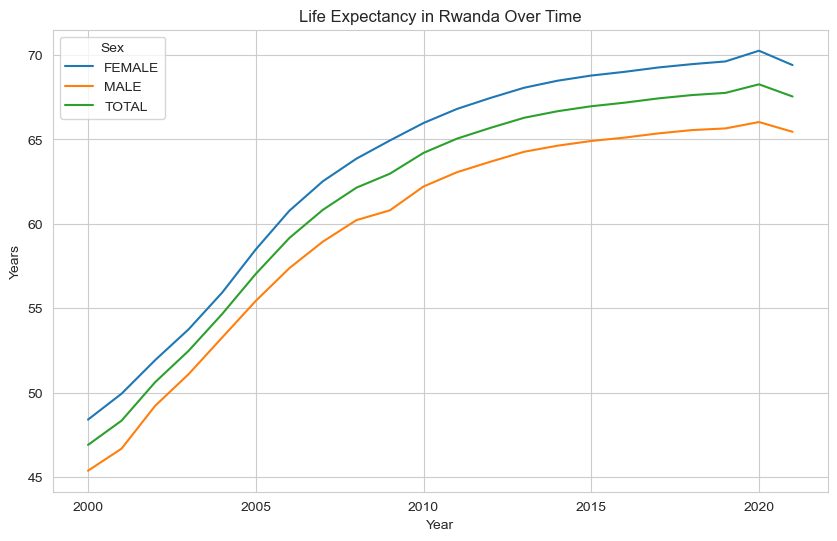

In [41]:
# Life expectancy over years
plt.figure(figsize=(10,6))  # Corrected parameter name
sns.lineplot(data=rwanda_life, x="Year", y="Life_Expectancy", hue="Sex")
plt.title("Life Expectancy in Rwanda Over Time")
plt.ylabel("Years")
plt.show()

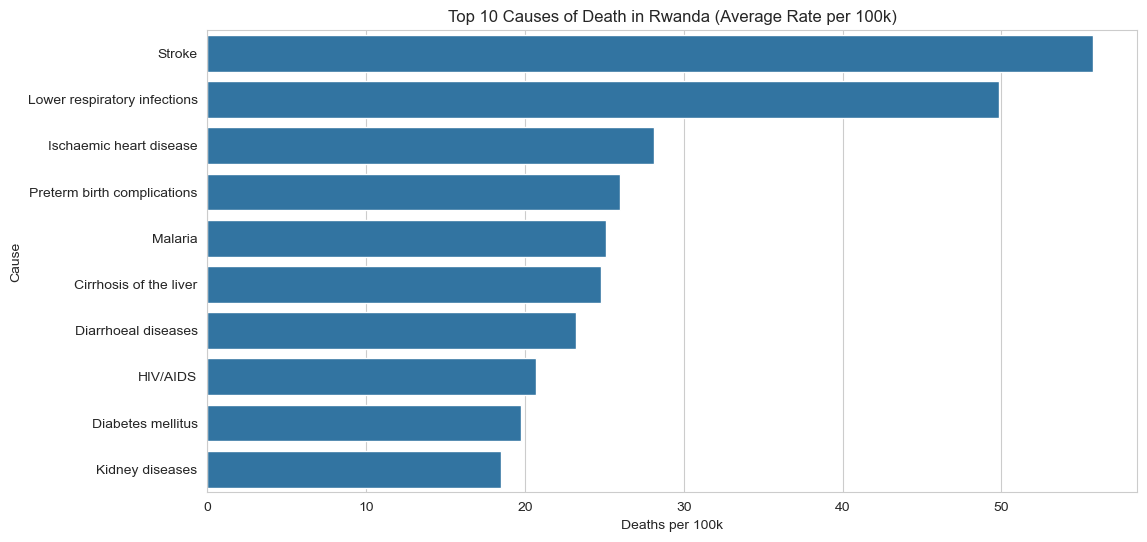

In [42]:
 #Top causes of death
top_causes = rwanda_deaths.groupby("Cause")["Deaths_per_100k"].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_causes.values, y=top_causes.index)
plt.title("Top 10 Causes of Death in Rwanda (Average Rate per 100k)")
plt.xlabel("Deaths per 100k")
plt.show()

7️. Insights & Analysis

Life expectancy has been increasing over the years, showing improvement in health outcomes.

Leading causes of death are mainly non-communicable diseases (stroke, heart disease), but infectious diseases like malaria still appear.

Differences in life expectancy between male and female populations.